# 02 · EDA – Valores faltantes y valores atípicos
**Responsable:** Andrés
**Objetivo:** revisar la calidad de los datos: duplicados, valores faltantes (incluidos los “escondidos”) y valores atípicos. Al final se guarda un dataset limpio (`data/processed/bank_limpio.csv`) que usan los siguientes notebooks.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # para poder importar src/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import (configurar_graficos, cargar_datos, guardar_figura,
                       VARIABLES_NUMERICAS, VARIABLES_CATEGORICAS, OBJETIVO,
                       RUTA_PROCESADOS)
configurar_graficos()
from scipy import stats
df = cargar_datos()
print(df.shape)

(41188, 21)


## 1. Duplicados y tipos de datos

In [2]:
print("Filas duplicadas:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Después de eliminar duplicados:", df.shape)
df.dtypes.value_counts()

Filas duplicadas: 12
Después de eliminar duplicados: (41176, 21)


str        10
int64       6
float64     5
Name: count, dtype: int64

## 2. Valores faltantes
A simple vista el dataset **no tiene nulos** (`NaN`). Sin embargo, la documentación indica que los faltantes vienen codificados:
- En variables categóricas como el texto **`unknown`**.
- En `pdays` como **999** = “el cliente nunca fue contactado antes” (no es un número real de días).

In [3]:
print("NaN explícitos:", df.isna().sum().sum())

faltantes = (df[VARIABLES_CATEGORICAS] == "unknown").sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
tabla_faltantes = pd.DataFrame({
    "n_unknown": faltantes,
    "porcentaje": (faltantes / len(df) * 100).round(2)
})
tabla_faltantes

NaN explícitos: 0


,n_unknown,porcentaje
default,8596,20.88
education,1730,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


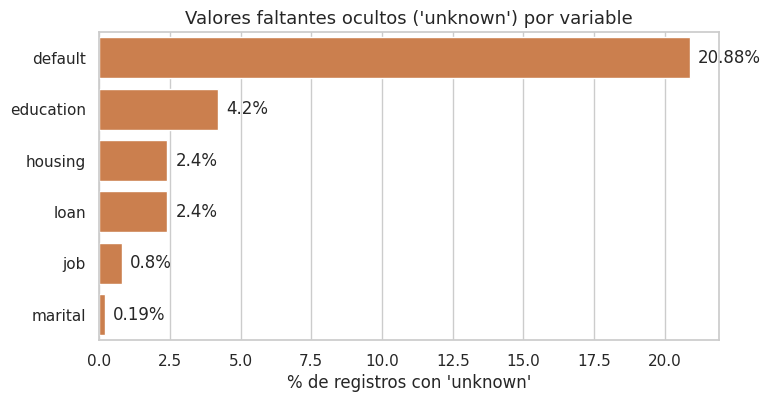

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=tabla_faltantes["porcentaje"], y=tabla_faltantes.index, ax=ax, color="#e07b39")
for i, v in enumerate(tabla_faltantes["porcentaje"]):
    ax.text(v + 0.3, i, f"{v}%", va="center")
ax.set_xlabel("% de registros con 'unknown'"); ax.set_ylabel("")
ax.set_title("Valores faltantes ocultos ('unknown') por variable")
guardar_figura("02_faltantes_por_variable")
plt.show()

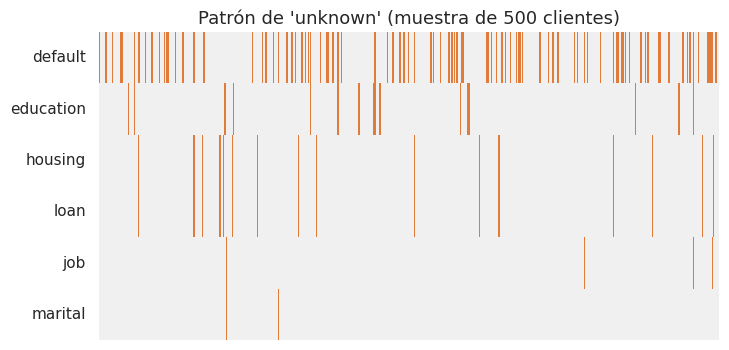

¿housing y loan son 'unknown' en las mismas filas? True


In [5]:
# Mapa de faltantes en una muestra de 500 filas (ver si aparecen juntos)
muestra = (df[tabla_faltantes.index] == "unknown").sample(500, random_state=42)
plt.figure(figsize=(8, 4))
sns.heatmap(muestra.T, cbar=False, cmap=["#f0f0f0", "#e07b39"], xticklabels=False)
plt.title("Patrón de 'unknown' (muestra de 500 clientes)")
guardar_figura("02_mapa_faltantes")
plt.show()

print("¿housing y loan son 'unknown' en las mismas filas?",
      ((df.housing == "unknown") == (df.loan == "unknown")).all())

In [6]:
# pdays = 999 -> nunca contactado
pct_999 = (df.pdays == 999).mean() * 100
print(f"pdays = 999 en el {pct_999:.1f}% de los registros")

pdays = 999 en el 96.3% de los registros


In [7]:
# ¿El faltante está relacionado con la variable objetivo?
for col in tabla_faltantes.index:
    tasa = df.groupby(df[col] == "unknown")[OBJETIVO].mean() * 100
    print(f"{col:10s} -> tasa de suscripción con dato: {tasa[False]:.1f}% | con 'unknown': {tasa[True]:.1f}%")

default    -> tasa de suscripción con dato: 12.9% | con 'unknown': 5.2%
education  -> tasa de suscripción con dato: 11.1% | con 'unknown': 14.5%
housing    -> tasa de suscripción con dato: 11.3% | con 'unknown': 10.8%
loan       -> tasa de suscripción con dato: 11.3% | con 'unknown': 10.8%
job        -> tasa de suscripción con dato: 11.3% | con 'unknown': 11.2%
marital    -> tasa de suscripción con dato: 11.3% | con 'unknown': 15.0%


In [8]:
print("Valores de 'default':")
print(df["default"].value_counts())

Valores de 'default':
default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64


### Estrategia de tratamiento de faltantes
| Variable | % unknown | Decisión | Justificación |
|---|---|---|---|
| default | ~20.9 % | **Conservar `unknown` como categoría** | Es demasiado alto para imputar y, además, casi nadie responde “yes” (solo 3 clientes). Los `unknown` suscriben 5,2 % vs 12,9 % de los que sí informan: el faltante *es informativo*. |
| education | ~4.2 % | Imputar con la **moda** | Porcentaje bajo. |
| housing / loan | ~2.4 % | Imputar con la **moda** | Faltan en las mismas filas; porcentaje bajo. |
| job / marital | < 1 % | Imputar con la **moda** | Impacto mínimo. |
| pdays = 999 | ~96 % | **Crear indicador** `contactado_antes` (0/1) | 999 no es un número real; usarlo como número distorsiona la media. |

In [9]:
df_limpio = df.copy()
for col in ["education", "housing", "loan", "job", "marital"]:
    moda = df_limpio.loc[df_limpio[col] != "unknown", col].mode()[0]
    df_limpio[col] = df_limpio[col].replace("unknown", moda)
    print(f"{col:10s} -> 'unknown' reemplazado por '{moda}'")

df_limpio["contactado_antes"] = (df_limpio["pdays"] != 999).astype(int)
print("\nUnknown restantes:", (df_limpio[VARIABLES_CATEGORICAS] == "unknown").sum().sum(), "(solo en 'default', a propósito)")

education  -> 'unknown' reemplazado por 'university.degree'
housing    -> 'unknown' reemplazado por 'yes'
loan       -> 'unknown' reemplazado por 'no'
job        -> 'unknown' reemplazado por 'admin.'
marital    -> 'unknown' reemplazado por 'married'

Unknown restantes: 8596 (solo en 'default', a propósito)


## 3. Valores atípicos
### 3.1 Método gráfico: boxplots

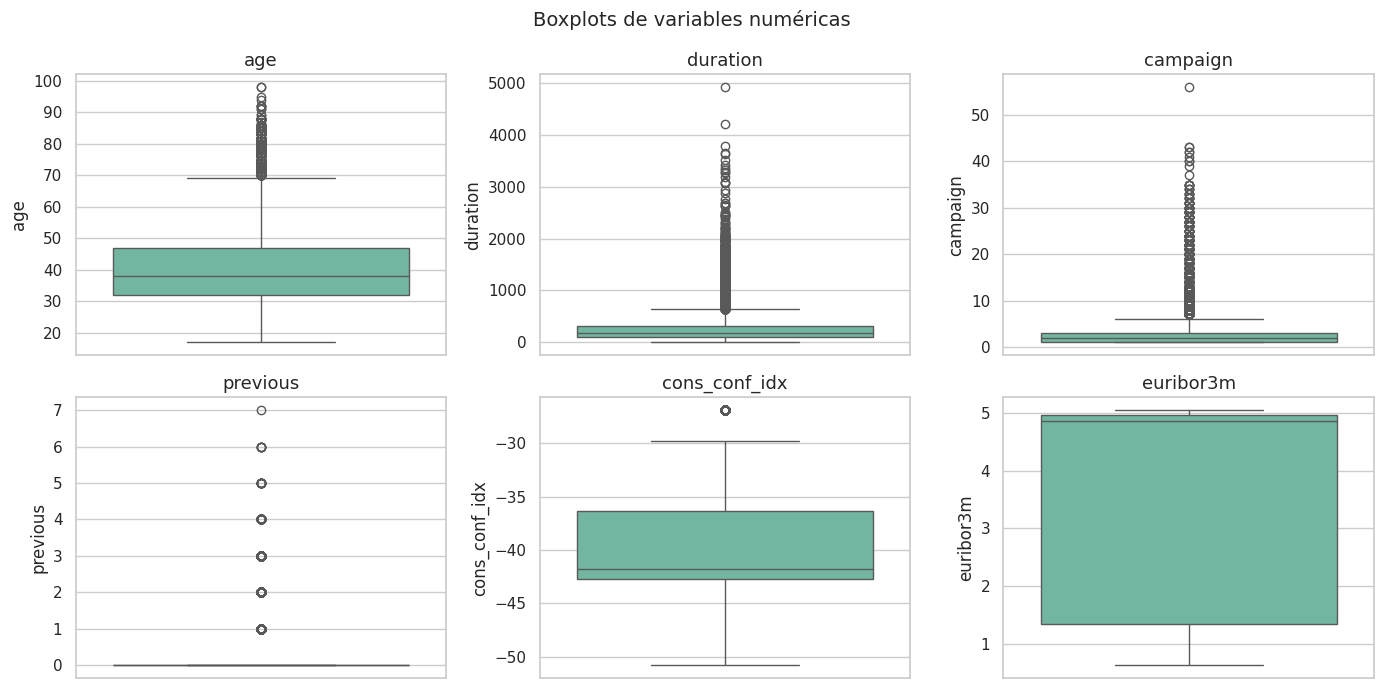

In [10]:
cols_outliers = ["age", "duration", "campaign", "previous", "cons_conf_idx", "euribor3m"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col, ax in zip(cols_outliers, axes.flat):
    sns.boxplot(y=df_limpio[col], ax=ax, color="#66c2a5")
    ax.set_title(col)
plt.suptitle("Boxplots de variables numéricas", fontsize=14)
plt.tight_layout()
guardar_figura("02_boxplots")
plt.show()

### 3.2 Métodos estadísticos: IQR y z-score

In [11]:
def outliers_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum(), q1 - 1.5 * iqr, q3 + 1.5 * iqr

filas = []
for col in VARIABLES_NUMERICAS:
    if col == "pdays":
        continue  # se trató como indicador
    n_iqr, li, ls = outliers_iqr(df_limpio[col])
    n_z = (np.abs(stats.zscore(df_limpio[col])) > 3).sum()
    filas.append([col, round(li, 2), round(ls, 2), n_iqr, round(n_iqr / len(df_limpio) * 100, 2), n_z,
                  round(n_z / len(df_limpio) * 100, 2)])
tabla_outliers = pd.DataFrame(filas, columns=["variable", "lim_inf_IQR", "lim_sup_IQR", "n_IQR", "%_IQR",
                                              "n_zscore>3", "%_zscore"]).set_index("variable")
tabla_outliers.sort_values("%_IQR", ascending=False)

,lim_inf_IQR,lim_sup_IQR,n_IQR,%_IQR,n_zscore>3,%_zscore
variable,,,,,,
previous,0.00,0.00,5625,13.66,1064,2.58
duration,-223.50,644.50,2963,7.20,861,2.09
campaign,-2.00,6.00,2406,5.84,869,2.11
age,9.50,69.50,468,1.14,369,0.90
cons_conf_idx,-52.15,-26.95,446,1.08,0,0.00
emp_var_rate,-6.60,6.20,0,0.00,0,0.00
cons_price_idx,91.70,95.37,0,0.00,0,0.00
euribor3m,-4.08,10.39,0,0.00,0,0.00
nr_employed,4905.60,5421.60,0,0.00,0,0.00


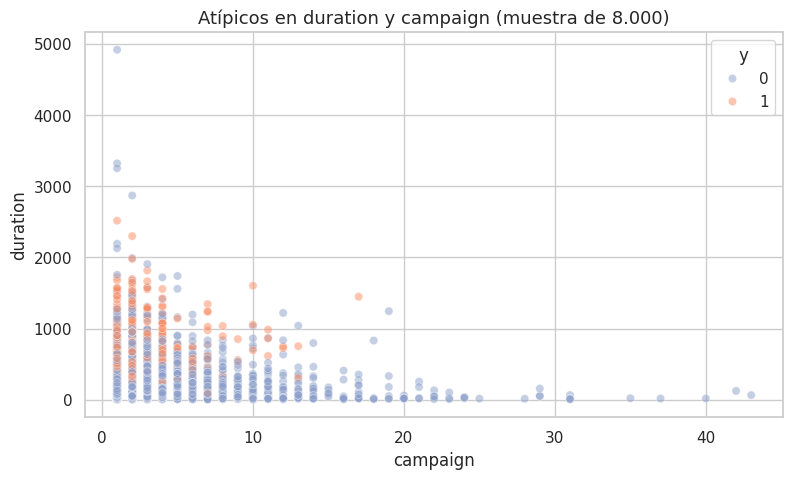

In [12]:
# Diagrama de dispersión: duración vs. número de contactos, coloreado por resultado
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_limpio.sample(8000, random_state=1), x="campaign", y="duration",
                hue=OBJETIVO, alpha=0.5, palette={0: "#8da0cb", 1: "#fc8d62"})
plt.title("Atípicos en duration y campaign (muestra de 8.000)")
guardar_figura("02_dispersion_outliers")
plt.show()

In [13]:
print("Casos extremos:")
print(" - Llamadas de más de 1 hora:", (df_limpio.duration > 3600).sum())
print(" - Clientes contactados más de 20 veces:", (df_limpio.campaign > 20).sum())
print(" - Tasa de éxito si campaign > 10:", round(df_limpio.loc[df_limpio.campaign > 10, OBJETIVO].mean() * 100, 1), "%")
print(" - Clientes mayores de 70 años:", (df_limpio.age > 70).sum())

Casos extremos:
 - Llamadas de más de 1 hora: 5
 - Clientes contactados más de 20 veces: 157
 - Tasa de éxito si campaign > 10: 3.1 %
 - Clientes mayores de 70 años: 421


### Decisión sobre los atípicos
- **age:** los atípicos (mayores de ~70 años) son **valores reales** (jubilados) y tienen alta tasa de suscripción → **se conservan**.
- **duration:** muy sesgada, con llamadas de más de 1 hora. Son reales → se conservan para el EDA. **Ojo:** la duración solo se conoce *después* de la llamada, por lo que **no debe usarse en un modelo predictivo** (fuga de información). Se eliminará en el preprocesamiento.
- **campaign:** hay clientes contactados hasta 56 veces. Se **acota (winsorización) al percentil 99** para reducir su influencia sin perder los registros.
- **previous:** los “atípicos” son simplemente clientes que sí tenían contactos previos; se conservan.
- **Variables macroeconómicas:** no presentan atípicos relevantes (son valores oficiales).

In [14]:
p99 = df_limpio["campaign"].quantile(0.99)
df_limpio["campaign"] = df_limpio["campaign"].clip(upper=p99)
print(f"campaign acotada a {p99:.0f} contactos (percentil 99)")

RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)
df_limpio.to_csv(RUTA_PROCESADOS / "bank_limpio.csv", index=False)
print("Dataset limpio guardado:", df_limpio.shape)

campaign acotada a 14 contactos (percentil 99)


Dataset limpio guardado: (41176, 22)


## 4. Resumen de calidad de datos
1. Había **12 filas duplicadas** que se eliminaron.
2. No hay `NaN`, pero sí **faltantes ocultos**: `default` (≈21 %), `education` (≈4 %), `housing`/`loan` (≈2,4 %, siempre juntos), `job` y `marital` (<1 %).
3. `pdays = 999` en ≈96 % de los registros: se transformó en el indicador `contactado_antes`.
4. Los atípicos más fuertes están en `duration` y `campaign`; son valores reales, no errores de digitación.
5. Se generó `data/processed/bank_limpio.csv` para el resto del análisis.

## Conclusiones: calidad de datos

- **Duplicados:** encontré y eliminé 12 filas duplicadas.
- **Faltantes ocultos:** `isna()` dio 0, pero los faltantes existen como el texto `unknown` y como `pdays = 999`. `default` es la variable más afectada (20,9 %), seguida de `education` (4,2 %), `housing` y `loan` (2,4 %). Además, `pdays = 999` aparece en el 96,3 % de los registros.
- **Tratamiento:** dejé `unknown` como categoría propia en `default`, porque quienes no responden suscriben mucho menos (5 % frente a 13 %), y eso es información útil. En las variables con menos del 5 % imputé con la moda. Con `pdays` creé el indicador `contactado_antes`.
- **Atípicos:** `duration` (cerca del 7 %) y `campaign` (hasta 56 llamadas) son los más extremos. Los traté como valores reales y no como errores, así que conservé `age` y `duration` y acoté `campaign` en el percentil 99 (14 llamadas) para que no distorsione los análisis posteriores.
- **Resultado:** el dataset limpio quedó guardado en `bank_limpio.csv` y es la base de los notebooks 03, 04 y 05.